# Загрузка и предварительная обработка данных
Был взят датасет Stocks Market


## **Загрузка датасета и создание персонализированного датасета**
Из-за большого объёма набора данных может потребоваться больше ресурсов для его обработки.
Выборочно возьмём отдельные файлы из всей совокупности для лабораторной работы.


In [96]:
import os
import glob
import pandas as pd

In [97]:
# путь к папке stocks
# r"" означает что обратные слэши не нужно экранировать
STOCKS_PATH = r"C:\Users\nikpa\OneDrive\Документы\Николя Учёба\Магистратура ВШЭ\1 курс\JupyterProject\data\stocks"

# находим все CSV файлы в папке
all_files = glob.glob(os.path.join(STOCKS_PATH, "*.csv"))

# просто проверяем сколько файлов нашлось
print(f"Найдено файлов: {len(all_files)}")

# печатаем первые 5 для проверки
for f in all_files[:5]:
    print(os.path.basename(f))


Найдено файлов: 5884
A.csv
AA.csv
AACG.csv
AAL.csv
AAMC.csv


In [98]:
# сортируем файлы по размеру — от большего к меньшему
# большой файл = больше исторических данных = больше строк
all_files_sorted = sorted(
    all_files,
    key=lambda f: os.path.getsize(f),
    reverse=True
)

# берём первые 100 файлов
files_to_use = all_files_sorted[:100]

# смотрим какие компании выбрались
print("Топ-15 крупнейших файлов:")
for f in files_to_use[:10]:
    size_kb = os.path.getsize(f) // 1024
    print(f"{os.path.basename(f):20} {size_kb} KB")

Топ-15 крупнейших файлов:
HPQ.csv              1628 KB
GE.csv               1606 KB
DIS.csv              1602 KB
ARNC.csv             1569 KB
AA.csv               1568 KB
IP.csv               1545 KB
MO.csv               1450 KB
BA.csv               1438 KB
KO.csv               1412 KB
MRO.csv              1362 KB


In [99]:
# список для хранения данных каждой компании
dataframes = []

for filepath in files_to_use:
    # читаем CSV файл
    df = pd.read_csv(filepath)

    # название компании из имени файла (убираем .csv)
    ticker = os.path.basename(filepath).replace(".csv", "")

    # добавляем колонку с названием компании
    df["ticker"] = ticker

    dataframes.append(df)

# объединяем все в одну таблицу
df_all = pd.concat(dataframes, ignore_index=True)

print(f"Итого строк: {len(df_all)}")
print(f"Итоговая размерность: {df_all.shape}")
print(f"Итого компаний: {df_all['ticker'].nunique()}")
print(f"\nКолонки: {list(df_all.columns)}")
print(f"\nПервые строки:")
df_all.head()

Итого строк: 1205202
Итоговая размерность: (1205202, 8)
Итого компаний: 100

Колонки: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'ticker']

Первые строки:


,Date,Open,High,Low,Close,Adj Close,Volume,ticker
0,1962-01-02,0.131273,0.131273,0.124177,0.124177,0.006887,2480300.0,HPQ
1,1962-01-03,0.124177,0.124177,0.121516,0.122846,0.006813,507300.0,HPQ
2,1962-01-04,0.122846,0.126838,0.117968,0.120185,0.006666,845500.0,HPQ
3,1962-01-05,0.119742,0.119742,0.117525,0.117525,0.006518,338200.0,HPQ
4,1962-01-08,0.117525,0.119299,0.115307,0.119299,0.006617,873700.0,HPQ


**Информация по признакам:**
* Date — Дата торгов
Дата конкретного торгового дня на бирже.

* Open — Цена открытия
Цена акции в момент открытия биржи в данный торговый день.

* High — Максимальная цена за день
Самая высокая цена акции за весь торговый день.

* Low — Минимальная цена за день
Самая низкая цена акции за весь торговый день.

* Close — Цена закрытия (скорректированная на сплиты)
Сплит — это когда компания делит каждую акцию на несколько частей.
Цена одной акции падает, но количество акций у владельца растёт пропорционально.
Реальная стоимость владения не меняется.

* Adj Close — Скорректированная цена закрытия (учитывает и сплиты, и дивиденды)
Adj Close делает всё то же что Close, но дополнительно учитывает дивиденды.
Дивиденды — это денежные выплаты компании своим акционерам из прибыли.
Когда компания выплачивает дивиденды, цена акции автоматически падает ровно на сумму дивиденда.
**Важно: Для предсказания тренда (вырастет/упадёт цена) используем Adj Close —
он даёт модели более честную картину реального движения цены**

* Volume — Объём торгов
Количество акций, которые сменили владельца за данный торговый день.
Высокий объём означает повышенный интерес к акции — это важный сигнал для модели.

* ticker — Тикер (название компании)
Краткое биржевое обозначение компании.
Этот признак добавлен при объединении файлов — в оригинальных CSV его не было.
Нужен чтобы после объединения понимать к какой компании относится каждая строка.

In [100]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205202 entries, 0 to 1205201
Data columns (total 8 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Date       1205202 non-null  object 
 1   Open       1205178 non-null  float64
 2   High       1205178 non-null  float64
 3   Low        1205178 non-null  float64
 4   Close      1205178 non-null  float64
 5   Adj Close  1205178 non-null  float64
 6   Volume     1205178 non-null  float64
 7   ticker     1205202 non-null  object 
dtypes: float64(6), object(2)
memory usage: 73.6+ MB


Есть пропуски.

In [101]:
# подсчёт пропусков в каждой колонке
print(df_all.isnull().sum())
print()
# процент пропусков (нагляднее)
total_rows = len(df_all)
print(df_all.isnull().sum() / total_rows * 100)

Date          0
Open         24
High         24
Low          24
Close        24
Adj Close    24
Volume       24
ticker        0
dtype: int64

Date         0.000000
Open         0.001991
High         0.001991
Low          0.001991
Close        0.001991
Adj Close    0.001991
Volume       0.001991
ticker       0.000000
dtype: float64


Пропусков мало. Можно удалить

In [102]:
df_all = df_all.dropna()
print(f"Размерность после удаления NaN: {df_all.shape}")

Размерность после удаления NaN: (1205178, 8)


**Проверка на дублирующиеся строки**

In [103]:
# сколько дубликатов
print(f"Дубликатов: {df_all.duplicated().sum()}")


Дубликатов: 0


**Обработка типов данных**

In [104]:
# исправление 1: конвертируем Date из строки в дату
# pd.to_datetime понимает большинство форматов дат автоматически
df_all["Date"] = pd.to_datetime(df_all["Date"])

# проверяем что получилось
print(f"Тип Date после конвертации: {df_all['Date'].dtype}")

Тип Date после конвертации: datetime64[ns]


Volume - объём продаж (количество акций, перешедших из рук в руки в течение определенного дня).
Имеет тип float, хотя логичнее, чтобы был тип int

In [105]:
# проверяем есть ли дробные значения
# если все значения целые — остаток от деления на 1 будет 0
has_fractional = (df_all["Volume"] % 1 != 0).sum()
print(f"Строк с дробным Volume: {has_fractional}")

Строк с дробным Volume: 0


In [106]:
# Volume делаем целым числом
df_all["Volume"] = df_all["Volume"].astype(int)

In [107]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1205178 entries, 0 to 1205201
Data columns (total 8 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   Date       1205178 non-null  datetime64[ns]
 1   Open       1205178 non-null  float64       
 2   High       1205178 non-null  float64       
 3   Low        1205178 non-null  float64       
 4   Close      1205178 non-null  float64       
 5   Adj Close  1205178 non-null  float64       
 6   Volume     1205178 non-null  int64         
 7   ticker     1205178 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 82.8+ MB


**Проверка на наличие выбросов**

Удаляем только физически невозможные значения

In [108]:
# # проверяем есть ли некорректные значения цен
# # цена акции не может быть нулевой или отрицательной
# print(f"Строк с нулевой или отрицательной ценой Close: {(df_all['Close'] <= 0).sum()}")
#
# # Volume = количество акций которые сменили владельца за день.
# # Если биржа открыта — хоть одна сделка должна быть совершена.
# # Нулевой объём означает либо ошибку данных,
# # либо что торгов в этот день не было.
# # Такие строки лучше удалить.
# print(f"Строк с нулевым или отрицательным Volume: {(df_all['Volume'] <= 0).sum()}")
#
# # проверяем логическое условие: Low всегда должен быть <= High
# # если Low > High — это ошибка в данных
# invalid_rows = (df_all["Low"] > df_all["High"]).sum()
# print(f"Строк где Low > High (ошибка): {invalid_rows}")
#
# # удаляем некорректные строки
# df_all = df_all[df_all["Close"] > 0]
# df_all = df_all[df_all["Volume"] > 0]
# df_all = df_all[df_all["Low"] <= df_all["High"]]
#
# print(f"\nСтрок после очистки выбросов: {len(df_all)}")

In [109]:
# # цена открытия должна быть в диапазоне [Low, High]
# invalid_open = ((df_all["Open"] < df_all["Low"]) |
#                 (df_all["Open"] > df_all["High"])).sum()
#
# # цена закрытия должна быть в диапазоне [Low, High]
# invalid_close = ((df_all["Close"] < df_all["Low"]) |
#                  (df_all["Close"] > df_all["High"])).sum()
#
# print(f"Строк где Open вне диапазона [Low, High]: {invalid_open}")
# print(f"Строк где Close вне диапазона [Low, High]: {invalid_close}")

In [110]:

# шаг 1: все ценовые колонки на отрицательные значения
# цена акции не может быть нулевой или отрицательной
print("-- Шаг 1: Отрицательные и нулевые значения --")
price_cols = ["Open", "High", "Low", "Close", "Adj Close"]
for col in price_cols:
    count = (df_all[col] <= 0).sum()
    print(f"  {col} <= 0: {count} строк")

# Volume = количество акций которые сменили владельца за день.
# Если биржа открыта — хоть одна сделка должна быть совершена.
# Нулевой объём означает либо ошибку данных,
# либо что торгов в этот день не было.
# Такие строки лучше удалить.
count_vol = (df_all["Volume"] <= 0).sum()
print(f"  Volume <= 0: {count_vol} строк")

# удаляем строки с некорректными ценами
for col in price_cols:
    df_all = df_all[df_all[col] > 0]
df_all = df_all[df_all["Volume"] > 0]
print(f"  Строк после очистки: {len(df_all)}\n")

# шаг 2: проверяем логическое условие: Low всегда должен быть <= High
# если Low > High — это ошибка в данных
print("-- Шаг 2: Логические противоречия --")
invalid_lh = (df_all["Low"] > df_all["High"]).sum()
print(f"  Low > High: {invalid_lh} строк")

df_all = df_all[df_all["Low"] <= df_all["High"]]
print(f"  Строк после очистки: {len(df_all)}\n")

# шаг 3: Open и Close в диапазоне [Low, High]
print("-- Шаг 3: Open и Close вне диапазона [Low, High] --")
invalid_open = ((df_all["Open"] < df_all["Low"]) |
                (df_all["Open"] > df_all["High"])).sum()
invalid_close = ((df_all["Close"] < df_all["Low"]) |
                 (df_all["Close"] > df_all["High"])).sum()
print(f"  Open вне [Low, High]: {invalid_open} строк")
print(f"  Close вне [Low, High]: {invalid_close} строк")

df_all = df_all[
    (df_all["Open"] >= df_all["Low"]) &
    (df_all["Open"] <= df_all["High"])
]
df_all = df_all[
    (df_all["Close"] >= df_all["Low"]) &
    (df_all["Close"] <= df_all["High"])
]
print(f"  Строк после очистки: {len(df_all)}\n")


print("-- Шаг 4: Статистические выбросы (IQR) --")
for col in ["Open", "High", "Low", "Close", "Adj Close", "Volume"]:
    Q1 = df_all[col].quantile(0.25)
    Q3 = df_all[col].quantile(0.75)
    IQR = Q3 - Q1
    count = ((df_all[col] < Q1 - 1.5*IQR) |
             (df_all[col] > Q3 + 1.5*IQR)).sum()
    print(f"  Выбросов {col}: {count} ({count/len(df_all)*100:.1f}%) — не удаляем")

print(f"\n=== Итого строк после всех проверок: {len(df_all)} ===")

-- Шаг 1: Отрицательные и нулевые значения --
  Open <= 0: 121257 строк
  High <= 0: 0 строк
  Low <= 0: 0 строк
  Close <= 0: 0 строк
  Adj Close <= 0: 0 строк
  Volume <= 0: 20710 строк
  Строк после очистки: 1063256

-- Шаг 2: Логические противоречия --
  Low > High: 0 строк
  Строк после очистки: 1063256

-- Шаг 3: Open и Close вне диапазона [Low, High] --
  Open вне [Low, High]: 26 строк
  Close вне [Low, High]: 1 строк
  Строк после очистки: 1063229

-- Шаг 4: Статистические выбросы (IQR) --
  Выбросов Open: 76388 (7.2%) — не удаляем
  Выбросов High: 76244 (7.2%) — не удаляем
  Выбросов Low: 76514 (7.2%) — не удаляем
  Выбросов Close: 76403 (7.2%) — не удаляем
  Выбросов Adj Close: 84550 (8.0%) — не удаляем
  Выбросов Volume: 98383 (9.3%) — не удаляем

=== Итого строк после всех проверок: 1063229 ===


**EDA. Более подробный взгляд на признаки.**

**Целевой признак**

Мы решаем задачу бинарной классификации — _предсказать направление движения цены акции на следующий день._
 * 1 -> цена завтра ВЫРАСТЕТ
 *  0 -> цена завтра УПАДЁТ или останется такой же

In [111]:
# сортируем по компании и дате — ОБЯЗАТЕЛЬНО перед shift
# если не сортировать — shift перепутает строки разных компаний
df_all = df_all.sort_values(["ticker", "Date"]).reset_index(drop=True)

# shift(-1) сдвигает колонку на одну строку вверх
# то есть для строки i мы получаем значение строки i+1 (следующий день)
# groupby("ticker") гарантирует что сдвиг происходит внутри одной компании

# Разбиваем таблицу на группы по компаниям.
df_all["target"] = (
    df_all.groupby("ticker")["Adj Close"].shift(-1) > df_all["Adj Close"]
).astype("Int64")

# последняя строка каждой компании получает NaN
# потому что у неё нет следующего дня — удаляем
df_all = df_all.dropna(subset=["target"])
df_all["target"] = df_all["target"].astype(int)

# проверяем результат
print("Распределение целевого признака:")
print(df_all["target"].value_counts())
print(f"\nПроцентное соотношение:")
print(df_all["target"].value_counts(normalize=True).mul(100).round(2))
print(f"\nВсего строк: {len(df_all)}")

Распределение целевого признака:
target
0    564161
1    499068
Name: count, dtype: int64

Процентное соотношение:
target
0    53.06
1    46.94
Name: proportion, dtype: float64

Всего строк: 1063229


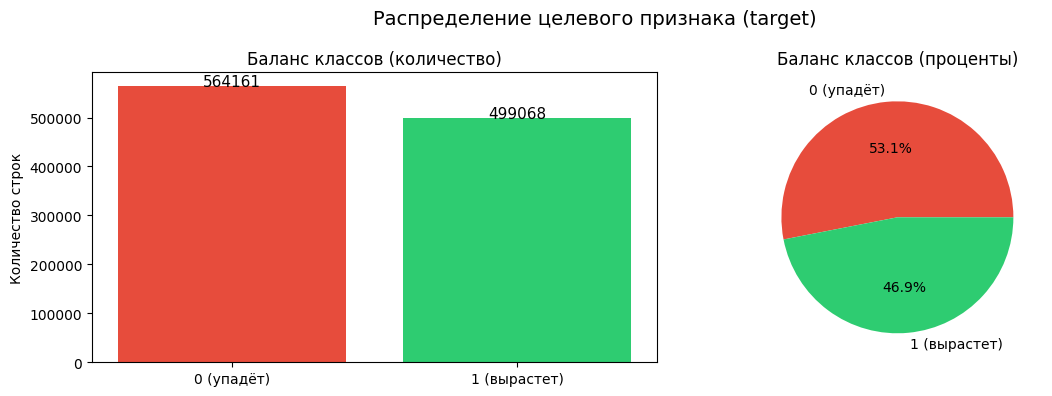

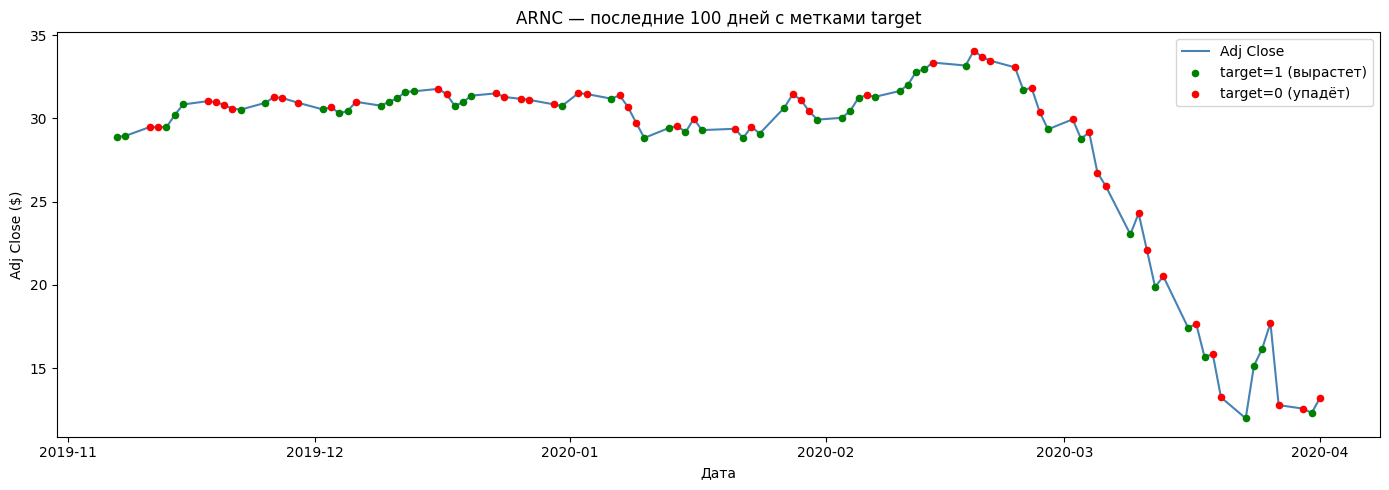

In [112]:
import matplotlib.pyplot as plt

# график 1: баланс классов (столбчатая диаграмма)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# подсчёт количества каждого класса
target_counts = df_all["target"].value_counts()
target_labels = ["0 (упадёт)", "1 (вырастет)"]

axes[0].bar(target_labels, target_counts.values, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Баланс классов (количество)")
axes[0].set_ylabel("Количество строк")

# подписываем столбцы значениями
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, str(v), ha="center", fontsize=11)

# график 2: процентное соотношение (круговая диаграмма)
target_pct = df_all["target"].value_counts(normalize=True) * 100
axes[1].pie(
    target_pct.values,
    labels=target_labels,
    autopct="%1.1f%%",
    colors=["#e74c3c", "#2ecc71"]
)
axes[1].set_title("Баланс классов (проценты)")

plt.suptitle("Распределение целевого признака (target)", fontsize=14)
plt.tight_layout()
plt.show()

# график 3: пример для одной компании — как target соотносится с ценой
# берём Arconic Corp. как пример
arconic = df_all[df_all["ticker"] == "ARNC"].tail(100)

plt.figure(figsize=(14, 5))
plt.plot(arconic["Date"], arconic["Adj Close"], color="steelblue", label="Adj Close")

# зелёные точки — дни где цена завтра выросла
plt.scatter(
    arconic[arconic["target"] == 1]["Date"],
    arconic[arconic["target"] == 1]["Adj Close"],
    color="green", label="target=1 (вырастет)", zorder=5, s=20
)

# красные точки — дни где цена завтра упала
plt.scatter(
    arconic[arconic["target"] == 0]["Date"],
    arconic[arconic["target"] == 0]["Adj Close"],
    color="red", label="target=0 (упадёт)", zorder=5, s=20
)

plt.title("ARNC — последние 100 дней с метками target")
plt.xlabel("Дата")
plt.ylabel("Adj Close ($)")
plt.legend()
plt.tight_layout()
plt.show()

Это приемлемый дисбаланс. Не идеальное 50/50, но разница всего 6%. Для решаемой задачи это не проблема.

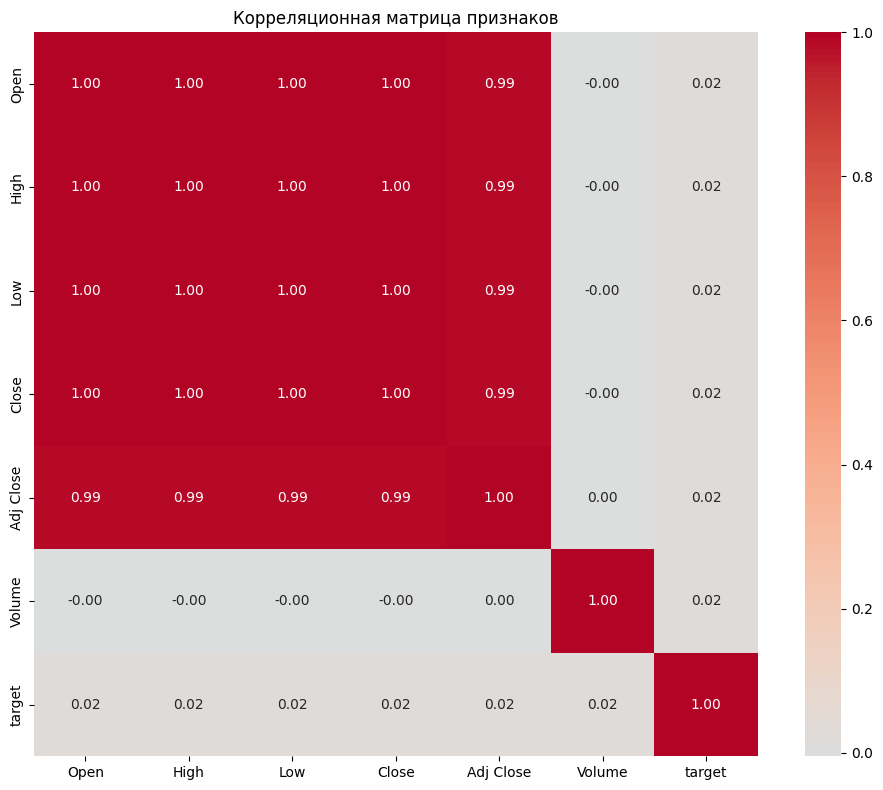

Корреляция признаков с target:
target       1.000000
Volume       0.023778
Adj Close    0.023274
Low          0.021090
Open         0.021048
High         0.021044
Close        0.020972
Name: target, dtype: float64


In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# берём только числовые признаки
numeric_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume", "target"]

correlation_matrix = df_all[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Корреляционная матрица признаков")
plt.tight_layout()
plt.show()

# печатаем корреляцию с целевым признаком отдельно
# это самое важное — что связано с тем что предсказываем
print("Корреляция признаков с target:")
print(correlation_matrix["target"].sort_values(ascending=False))

Видим сильную корреляцию между несколькими признаками. Есть мультиколлинеарность между этими признаками.
Создадим новые на их основе.

In [114]:
# шаг 1: создаём volatility ПЕРВЫМ — пока High и Low ещё существуют
# волатильность = разница между максимумом и минимумом дня
# данные уже нормализованы поэтому volatility тоже будет в диапазоне 0-1
df_all["volatility"] = df_all["High"] - df_all["Low"]

# шаг 2: создаём остальные новые признаки

# MA5 — средняя цена Adj Close за последние 5 дней
# groupby гарантирует что считаем внутри каждой компании отдельно
df_all["MA5"] = df_all.groupby("ticker")["Adj Close"].transform(
    lambda x: x.rolling(window=5).mean()
)

# MA20 — средняя цена Adj Close за последние 20 дней
df_all["MA20"] = df_all.groupby("ticker")["Adj Close"].transform(
    lambda x: x.rolling(window=20).mean()
)

# процентное изменение цены относительно предыдущего дня
# pct_change() = (сегодня - вчера) / вчера
df_all["price_change"] = df_all.groupby("ticker")["Adj Close"].transform(
    lambda x: x.pct_change()
)

# день недели: 0=понедельник, 4=пятница
df_all["day_of_week"] = df_all["Date"].dt.dayofweek

# месяц: 1=январь, 12=декабрь
df_all["month"] = df_all["Date"].dt.month

# шаг 3: удаляем ненужные колонки
# Open, High, Low — дублируют информацию Adj Close (корреляция 0.99-1.00)
# Close — заменён на Adj Close (более честная цена)
df_all = df_all.drop(columns=["Open", "High", "Low", "Close"])

# шаг 4: удаляем строки с NaN
# первые 19 строк каждой компании не имеют достаточно истории для MA20
df_all = df_all.dropna()

# шаг 5: проверяем результат
print(f"Строк после всех операций: {len(df_all)}")
print(f"\nКолонки которые остались:")
print(list(df_all.columns))
print(f"\nПроверка NaN:")
print(df_all.isnull().sum())
print(f"\nПервые строки:")
df_all.head()

Строк после всех операций: 1061329

Колонки которые остались:
['Date', 'Adj Close', 'Volume', 'ticker', 'target', 'volatility', 'MA5', 'MA20', 'price_change', 'day_of_week', 'month']

Проверка NaN:
Date            0
Adj Close       0
Volume          0
ticker          0
target          0
volatility      0
MA5             0
MA20            0
price_change    0
day_of_week     0
month           0
dtype: int64

Первые строки:


,Date,Adj Close,Volume,ticker,target,volatility,MA5,MA20,price_change,day_of_week,month
19,1962-01-29,1.393449,42500,AA,1,0.040050,1.399291,1.458270,-0.001351,0,1
20,1962-01-30,1.402871,30500,AA,0,0.032040,1.396841,1.451580,0.006762,1,1
21,1962-01-31,1.400986,55900,AA,0,0.060075,1.396841,1.443619,-0.001344,2,1
22,1962-02-01,1.395334,67900,AA,0,0.092115,1.397595,1.435375,-0.004034,3,2
23,1962-02-02,1.391565,30500,AA,1,0.048060,1.396841,1.427037,-0.002701,4,2


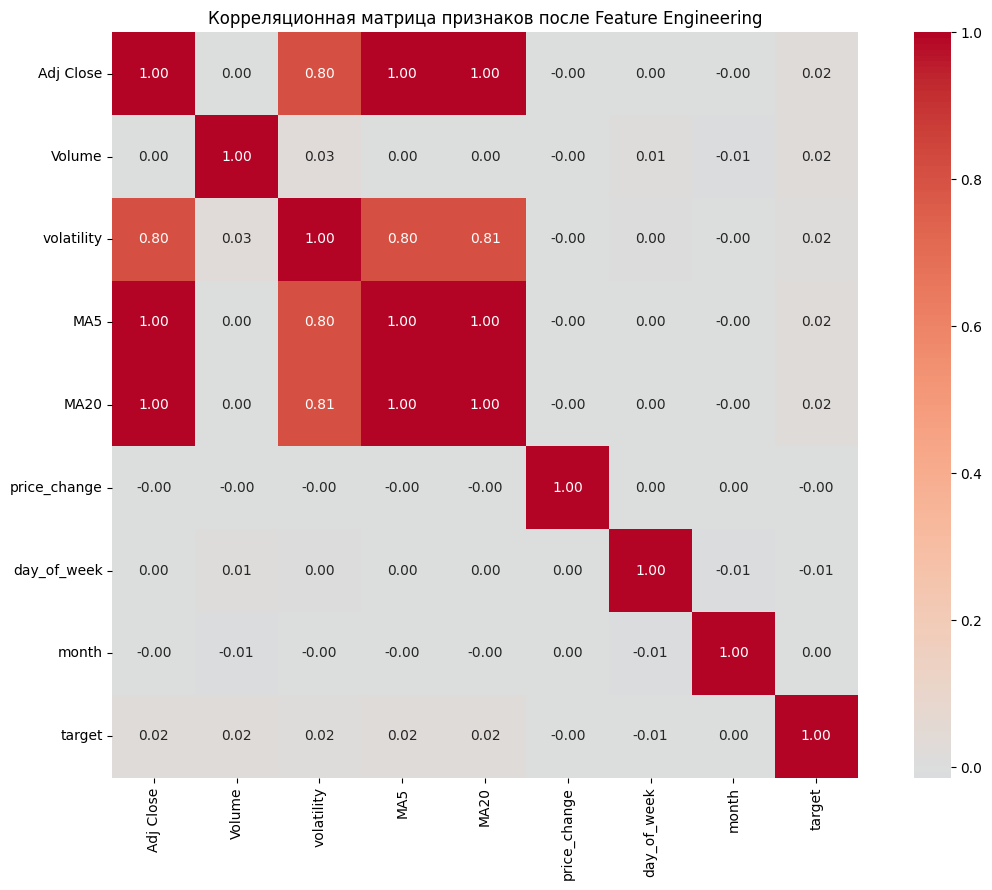

Корреляция каждого признака с target (по убыванию):
Volume          0.023648
MA20            0.023465
MA5             0.023305
Adj Close       0.023172
volatility      0.015358
day_of_week    -0.006044
price_change   -0.000678
month           0.000298
Name: target, dtype: float64


In [117]:
# список только числовых признаков для корреляции
# Date и ticker не включаем — они не числовые
numeric_cols = ["Adj Close", "Volume", "volatility", "MA5",
                "MA20", "price_change", "day_of_week", "month", "target"]

# считаем корреляцию между всеми парами признаков
correlation_matrix = df_all[numeric_cols].corr()

# рисуем матрицу
plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Корреляционная матрица признаков после Feature Engineering")
plt.tight_layout()
plt.show()

# отдельно печатаем корреляцию с target — это самое важное
print("Корреляция каждого признака с target (по убыванию):")
print(correlation_matrix["target"].drop("target").sort_values(
    key=abs, ascending=False
))


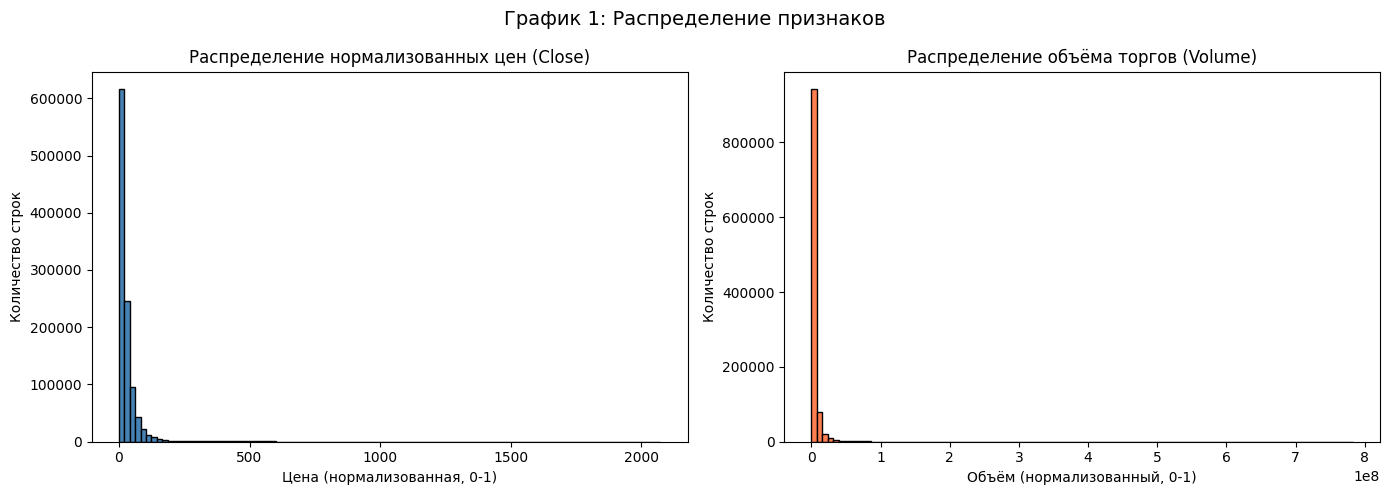

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# гистограмма цен Close
# bins=50 — делим диапазон цен на 50 интервалов
axes[0].hist(df_all["Close"], bins=100, color="steelblue", edgecolor="black")
axes[0].set_title("Распределение цен (Close)")
axes[0].set_xlabel("Цена")
axes[0].set_ylabel("Количество строк")

# большинство значений будет около 0 — это логично
# большинство акций стоят дёшево по сравнению с максимумом

# гистограмма объёма торгов
axes[1].hist(df_all["Volume"], bins=100, color="coral", edgecolor="black")
axes[1].set_title("Распределение объёма торгов (Volume)")
axes[1].set_xlabel("Объём (нормализованный, 0-1)")
axes[1].set_ylabel("Количество строк")

plt.suptitle("График 1: Распределение признаков", fontsize=14)
plt.tight_layout()
plt.show()

# Нормализация

In [47]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# колонки которые нормализуем — только числовые признаки
# Date, ticker, target НЕ нормализуем:
# Date — это дата, не признак для модели
# ticker — строка
# target — это метка класса (0 или 1), её нельзя трогать
features_to_scale = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]

# создаём объект нормализатора
scaler = MinMaxScaler()

# fit_transform делает два действия:
# fit — изучает данные (находит минимум и максимум каждой колонки)
# transform — применяет формулу нормализации
df_all[features_to_scale] = scaler.fit_transform(df_all[features_to_scale])

# проверяем результат — все значения должны быть от 0 до 1
print("Минимальные значения после нормализации:")
print(df_all[features_to_scale].min())
print("\nМаксимальные значения после нормализации:")
print(df_all[features_to_scale].max())
print("\nПример первых строк после нормализации:")
print(df_all[features_to_scale].head())

Минимальные значения после нормализации:
Open         0.0
High         0.0
Low          0.0
Close        0.0
Adj Close    0.0
Volume       0.0
dtype: float64

Максимальные значения после нормализации:
Open         1.0
High         1.0
Low          1.0
Close        1.0
Adj Close    1.0
Volume       1.0
dtype: float64

Пример первых строк после нормализации:
       Open      High       Low     Close  Adj Close    Volume
0  0.003131  0.003133  0.003188  0.003128   0.001025  0.000071
1  0.003131  0.003170  0.003184  0.003176   0.001040  0.000095
2  0.003180  0.003185  0.003237  0.003176   0.001040  0.000103
3  0.003180  0.003182  0.003229  0.003172   0.001039  0.000090
4  0.003168  0.003158  0.003093  0.003068   0.001005  0.000120


Когда потом Consumer будет получать новые данные из Kafka — он должен нормализовать их теми же самыми параметрами (теми же минимумами и максимумами). Иначе модель получит данные в другом масштабе и будет давать неправильные предсказания.

In [50]:
# сохраняем скалер в папку models
joblib.dump(scaler, "models/scaler.pkl")

print("Скалер сохранён в models/scaler.pkl")

# проверяем что файл создался
import os
print(f"Размер файла: {os.path.getsize('models/scaler.pkl')} байт")

Скалер сохранён в models/scaler.pkl
Размер файла: 1207 байт


После нормализации сохраняем датасет — он понадобится для обучения модели

In [51]:
df_all.to_csv("data/dataset_combined.csv", index=False)

print(f"Датасет сохранён в data/dataset_combined.csv")
print(f"Итого строк: {len(df_all)}")
print(f"Итого колонок: {len(df_all.columns)}")
print(f"Колонки: {list(df_all.columns)}")

Датасет сохранён в data/dataset_combined.csv
Итого строк: 1063229
Итого колонок: 9
Колонки: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'ticker', 'target']


# EDA. Изучим признаки более подробно.

 Распределение цен